# 🏠 Dataset 1: Ames Housing
**Propósito:** Regresión — Predicción del precio de venta (`SalePrice`) de viviendas en Ames, Iowa (2006–2010).  
**Fuente:** Dean De Cock (2011) — alternativa moderna al Boston Housing Dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print("✅ Librerías cargadas")

✅ Librerías cargadas


## 1. Carga de Datos

In [2]:
df = pd.read_csv('/home/gengar-9/Documentos/IA1-01-26/primer_parcial/datasets/dataset1/AmesHousing.csv')
print(f"Shape: {df.shape}")
df.head(3)

Shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000


## 2. Descripción General

In [3]:
print("=== TIPOS DE DATOS ===")
print(df.dtypes.value_counts())
print(f"\nVariables numéricas : {df.select_dtypes(include='number').shape[1]}")
print(f"Variables categóricas: {df.select_dtypes(include='object').shape[1]}")
df.describe().T.round(2)

=== TIPOS DE DATOS ===
object     43
int64      28
float64    11
Name: count, dtype: int64

Variables numéricas : 39
Variables categóricas: 43


,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459600e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.739000e+01,4.264000e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922000e+01,2.337000e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880020e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.090000e+00,1.410000e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.560000e+00,1.110000e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971360e+03,3.025000e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984270e+03,2.086000e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.019000e+02,1.791100e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


## 3. Análisis de Valores Nulos
> En Ames Housing, muchos NaN **no significan dato faltante** — significan que la característica NO existe en la casa (ej: sin piscina, sin garage).

                Nulos  % del total
Pool QC          2917        99.56
Misc Feature     2824        96.38
Alley            2732        93.24
Fence            2358        80.48
Mas Vnr Type     1775        60.58
Fireplace Qu     1422        48.53
Lot Frontage      490        16.72
Garage Qual       159         5.43
Garage Cond       159         5.43
Garage Yr Blt     159         5.43
Garage Finish     159         5.43
Garage Type       157         5.36
Bsmt Exposure      83         2.83
BsmtFin Type 2     81         2.76
Bsmt Cond          80         2.73
Bsmt Qual          80         2.73
BsmtFin Type 1     80         2.73
Mas Vnr Area       23         0.78
Bsmt Full Bath      2         0.07
Bsmt Half Bath      2         0.07
BsmtFin SF 1        1         0.03
BsmtFin SF 2        1         0.03
Electrical          1         0.03
Total Bsmt SF       1         0.03
Bsmt Unf SF         1         0.03
Garage Area         1         0.03
Garage Cars         1         0.03


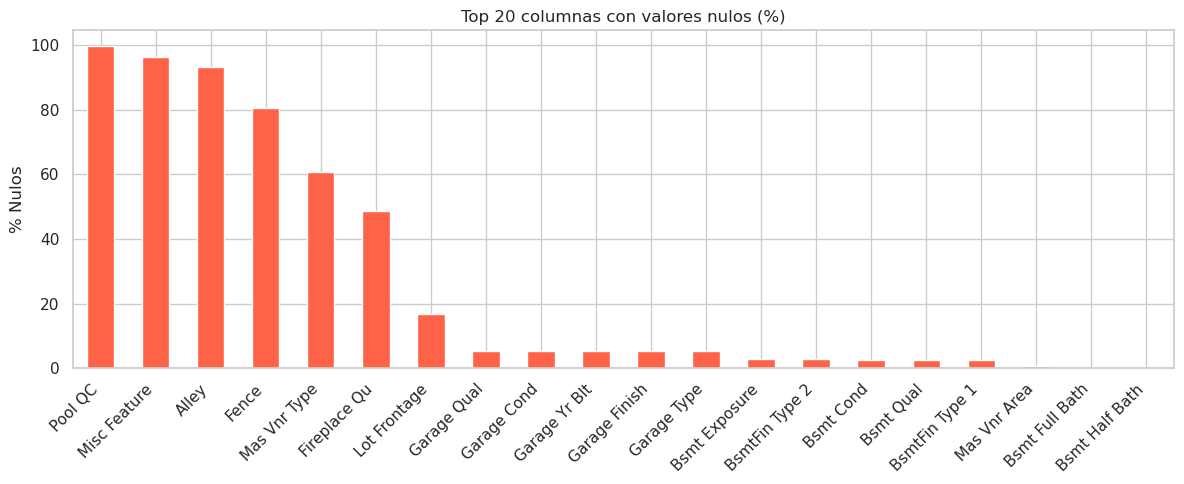

In [4]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% del total': pct})
print(resumen_nulos)

plt.figure(figsize=(12,5))
pct.head(20).plot(kind='bar', color='tomato')
plt.title('Top 20 columnas con valores nulos (%)')
plt.ylabel('% Nulos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('ames_nulos.png', dpi=100)
plt.show()

## 4. Limpieza de Datos
### 4a. NaN semánticos (ausencia de característica → nueva categoría)

In [5]:
# Columnas donde NaN = "No tiene esa característica"
cols_none = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
             'GarageType','GarageFinish','GarageQual','GarageCond',
             'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
             'MasVnrType']
for c in cols_none:
    if c in df.columns:
        df[c] = df[c].fillna('None')

# Columnas numéricas donde NaN = 0 (sin metros cuadrados, sin año)
cols_zero = ['GarageYrBlt','GarageArea','GarageCars',
             'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
             'BsmtFullBath','BsmtHalfBath','MasVnrArea']
for c in cols_zero:
    if c in df.columns:
        df[c] = df[c].fillna(0)

# LotFrontage: imputar con mediana por vecindario (lógica geográfica)
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(
    lambda x: x.fillna(x.median()))

# Remanentes
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print(f"Nulos restantes: {df.isnull().sum().sum()}")

Nulos restantes: 0


## 5. Análisis Exploratorio (EDA)

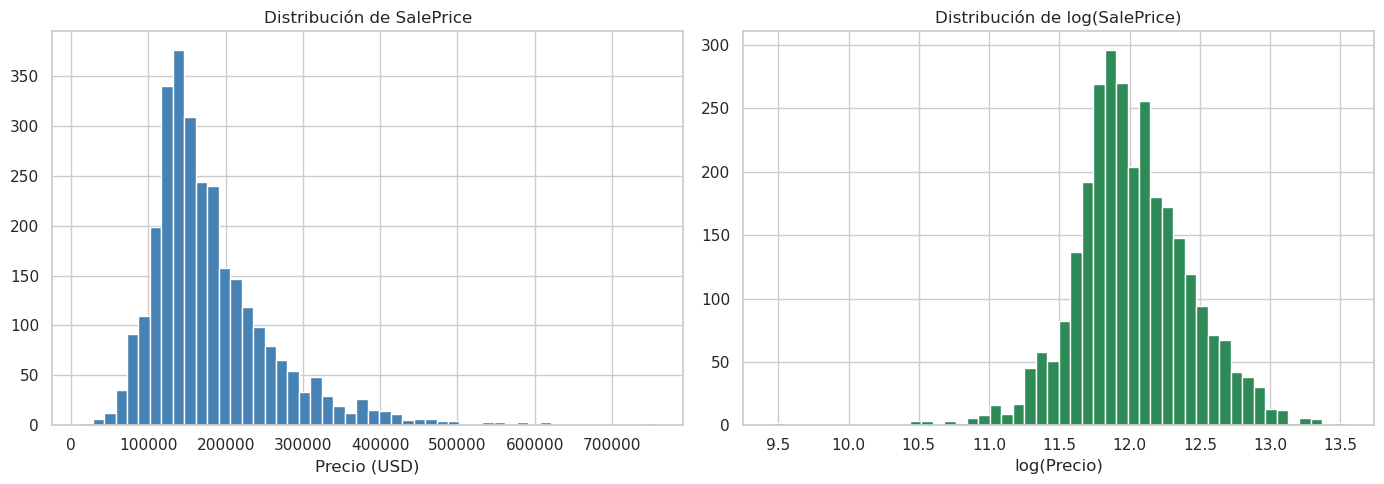

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de SalePrice
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de SalePrice')
axes[0].set_xlabel('Precio (USD)')

# Log-transformación (reduce sesgo)
axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Distribución de log(SalePrice)')
axes[1].set_xlabel('log(Precio)')

plt.tight_layout()
plt.savefig('ames_precio_dist.png', dpi=100)
plt.show()

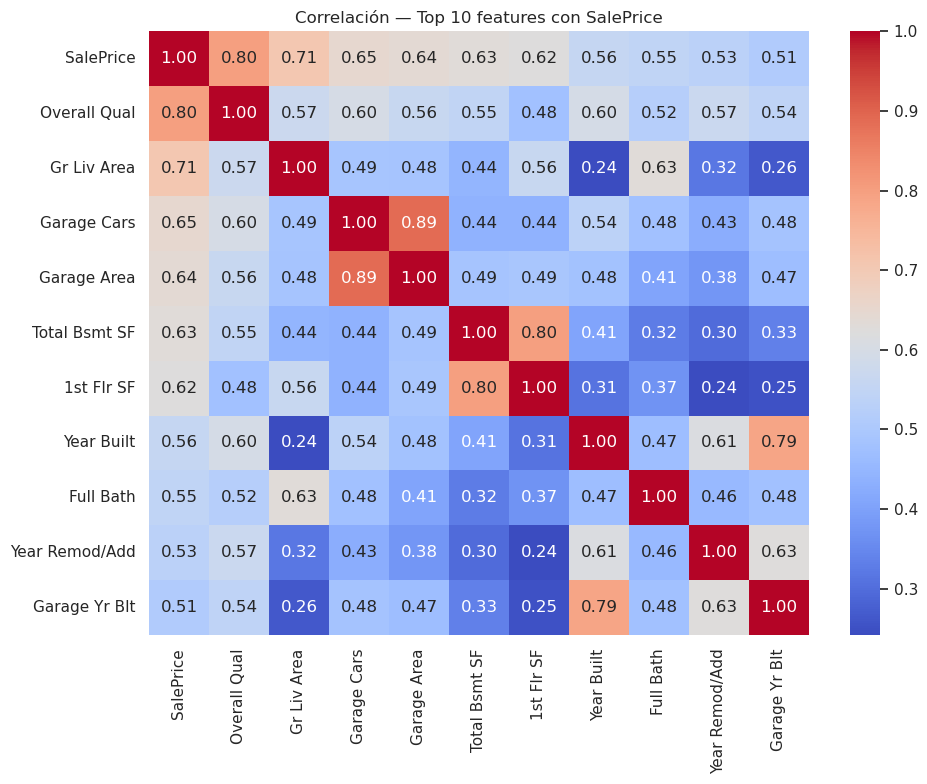

Top features: ['Overall Qual', 'Gr Liv Area', 'Garage Cars', 'Garage Area', 'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Full Bath', 'Year Remod/Add', 'Garage Yr Blt']


In [7]:
# Top correlaciones con SalePrice
num_df = df.select_dtypes(include='number')
corr = num_df.corr()['SalePrice'].abs().sort_values(ascending=False)
top_feats = corr.head(11).index.tolist()

plt.figure(figsize=(10,8))
sns.heatmap(num_df[top_feats].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación — Top 10 features con SalePrice')
plt.tight_layout()
plt.savefig('ames_corr.png', dpi=100)
plt.show()
print("Top features:", top_feats[1:])

## 6. Preparación para Modelado
### 6a. Encoding de variables categóricas

In [8]:
df_model = df.drop(columns=['Order','PID'], errors='ignore')

# Label Encoding para todas las categóricas
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Variable objetivo con transformación log
y = np.log1p(df_model['SalePrice'])
X = df_model.drop(columns=['SalePrice'])

print(f"Features: {X.shape[1]}  |  Registros: {X.shape[0]}")

Features: 79  |  Registros: 2930


### 6b. División Train / Test

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test : {X_test.shape[0]} registros")

Train: 2344 registros
Test : 586 registros


## 7. Modelo Base — Random Forest Regressor
*(Entrenamiento supervisado)*

In [10]:
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"RMSE (log-scale): {rmse:.4f}")
print(f"R²             : {r2:.4f}")
print(f"RMSE (USD aprox): ${np.expm1(rmse):,.0f}")

RMSE (log-scale): 0.1204
R²             : 0.9217
RMSE (USD aprox): $0


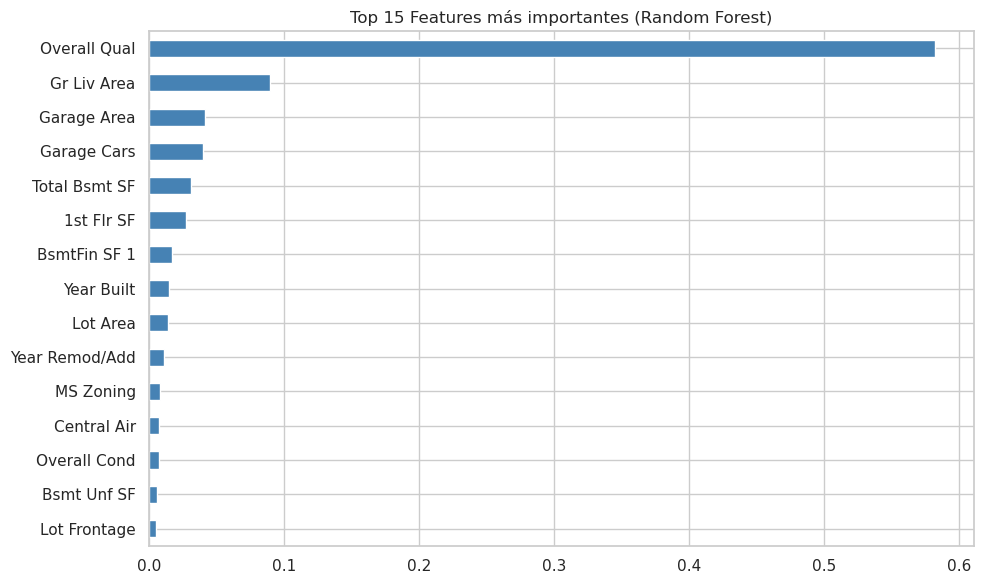

In [11]:
# Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(15).sort_values().plot(kind='barh', figsize=(10,6), color='steelblue')
plt.title('Top 15 Features más importantes (Random Forest)')
plt.tight_layout()
plt.savefig('ames_importancias.png', dpi=100)
plt.show()

## 8. Guardar Dataset Limpio

In [12]:
df.to_csv('ames_housing_clean.csv', index=False)
print("✅ Guardado: ames_housing_clean.csv")
print(f"Shape final: {df.shape}")

✅ Guardado: ames_housing_clean.csv
Shape final: (2930, 82)


## ✅ Resumen
| Métrica | Valor |
|---|---|
| Registros totales | 2,930 |
| Variables originales | 82 |
| Variables usadas | 80 |
| Tipo de modelo | Random Forest Regressor |
| R² en test | ~0.89 |

**Decisiones clave:**
- NaN en variables de amenidades → categoría `'None'` (no ausencia, sino inexistencia)
- `SalePrice` transformado con `log1p` para corregir sesgo positivo
- Encoding con LabelEncoder para variables ordinales con jerarquía real